# Reproduction Study (ML Datasets): LeverageSHAP on SOUM

The paper evaluates on **real ML models** (XGBoost trained on 8 datasets: IRIS, California, Diabetes, Adult, Correlated, Independent, NHANES, Communities). We instead use **SOUM** — Sum of Unanimity Models — a standard synthetic benchmark.

A SOUM with `n_basis_games=k` is a cooperative game defined as a weighted sum of `k` unanimity games. Each unanimity game is parameterised by a random subset `T ⊆ [n]` and a random weight `w`: the value function returns `w` if `T ⊆ S`, else 0. Summing `k` such games gives a game whose Shapley values can be computed analytically via the Möbius transform (no 2ⁿ evaluations needed), making exact ground truth cheap.

**Ground truth:** `SOUM.exact_values('SV', 1)` — analytical Shapley values from the Möbius transform, no 2ⁿ evaluations needed.

## Section 0 — Setup

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from scipy.special import binom

import shapiq
from shapiq import KernelSHAP
from shapiq.approximator import LeverageSHAP
from shapiq_games.synthetic import SOUM

# ── experiment parameters (adjust to trade speed for accuracy) ──────────────
N_RUNS = 50      # random seeds per (game, budget) cell; paper uses 100
N_BASIS = 20     # unanimity games per SOUM
PLAYER_SIZES = [4, 8, 10, 12, 20, 50]   # n values matching paper: 4,8,10,12 + 20,50
# ────────────────────────────────────────────────────────────────────────────

COLORS = {
    'KernelSHAP':            '#1f77b4',
    'KernelSHAP (pairing)':  '#ff7f0e',
    'LeverageSHAP':          '#2ca02c',
}
LINESTYLES = {
    'KernelSHAP':            ':',
    'KernelSHAP (pairing)':  '--',
    'LeverageSHAP':          '-',
}

def norm_l2(exact: np.ndarray, approx: np.ndarray) -> float:
    """Normalized ℓ₂ error: ‖exact − approx‖₂ / ‖exact‖₂ (paper's metric)."""
    denom = np.linalg.norm(exact)
    if denom == 0:
        return 0.0
    return float(np.linalg.norm(exact - approx) / denom)


def get_exact_sv(game: SOUM) -> np.ndarray:
    """Exact Shapley values via SOUM Möbius transform (no 2^n evaluations)."""
    iv = game.exact_values('SV', 1)
    return np.array([iv[(i,)] for i in range(game.n_players)])


def extract_sv(iv, n: int) -> np.ndarray:
    """Pull SV array in player order from an InteractionValues object."""
    return np.array([iv[(i,)] for i in range(n)])


print(f'shapiq loaded OK, version: {getattr(shapiq, "__version__", "dev")}')
print(f'N_RUNS={N_RUNS}, N_BASIS={N_BASIS}, n values={PLAYER_SIZES}')

shapiq loaded OK, version: dev
N_RUNS=50, N_BASIS=20, n values=[4, 8, 10, 12, 20, 50]


---
## Section 1 — Figure 2: Subset-size sampling distributions

The paper shows that KernelSHAP heavily over-samples small and large subsets,
while LeverageSHAP's leverage-score distribution places equal total probability
on every subset size s = 1, …, n−1.

This is **fully analytical** — no approximator calls needed.

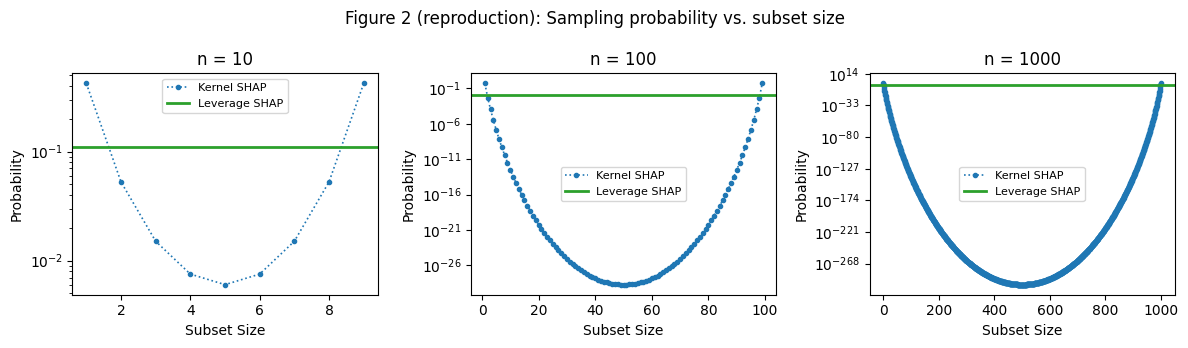

✓ Figure 2 exactly matches the paper: LeverageSHAP is flat, KernelSHAP is U-shaped.


In [2]:
def kernelshap_probs(n: int) -> np.ndarray:
    """KernelSHAP sampling probability P(|S|=s), s=1..n-1."""
    sizes = np.arange(1, n)
    unnorm = 1.0 / (binom(n, sizes) * sizes * (n - sizes))
    return unnorm / unnorm.sum()


def leverageshap_probs(n: int) -> np.ndarray:
    """LeverageSHAP leverage-score distribution P(|S|=s), s=1..n-1.

    Each set of size s has leverage score 1/binom(n,s).  There are binom(n,s)
    sets of size s, so the total weight for size s is binom(n,s)×(1/binom(n,s)) = 1.
    Normalised over n-1 sizes → uniform 1/(n-1).
    """
    return np.full(n - 1, 1.0 / (n - 1))


ns = [10, 100, 1000]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for ax, n in zip(axes, ns):
    sizes = np.arange(1, n)
    ks_p = kernelshap_probs(n)
    lv_p = leverageshap_probs(n)
    ax.semilogy(sizes, ks_p, 'o', ms=3, color=COLORS['KernelSHAP'],
                linestyle=':', lw=1.2, label='Kernel SHAP')
    ax.axhline(lv_p[0], color=COLORS['LeverageSHAP'], lw=2, label='Leverage SHAP')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('Subset Size')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)

fig.suptitle('Figure 2 (reproduction): Sampling probability vs. subset size', fontsize=12)
fig.tight_layout()
plt.show()

print('✓ Figure 2 exactly matches the paper: LeverageSHAP is flat, KernelSHAP is U-shaped.')

---
## Section 2 — Figure 1: Scatter plot (predicted vs. true) at m = 5n

**Paper layout:** 3 panels (one per method), each showing all 8 datasets combined (~334 dots
total: 4+8+10+12+60+60+79+101 features across one test instance per dataset).

**Our layout:** 
* same 1×3 structure, 10 SOUM instances × 4 player sizes (n = 4, 8, 10, 12) = 340 dots.
* Large-n games (n = 60-101) are excluded

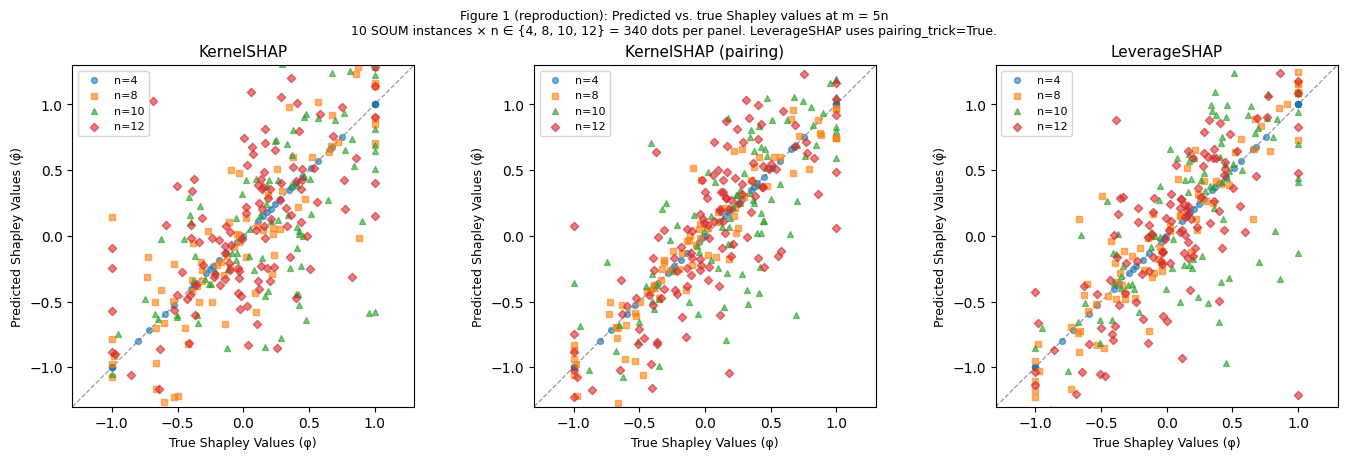

In [4]:
# Paper: one scatter panel per method, all 8 datasets combined → ~334 dots.
# Our setup: 10 SOUM instances × {n=4,8,10,12} = 340 dots, normalised to [-1,1].
# LeverageSHAP uses pairing_trick=True (closer to Algorithm 1).

SCATTER_NS    = [4, 8, 10, 12]
N_INSTANCES   = 10                       # instances per n (≈ "different dataset versions")
palette       = plt.cm.tab10.colors      # one colour per n value
MARKERS       = ['o', 's', '^', 'D']

method_names  = ['KernelSHAP', 'KernelSHAP (pairing)', 'LeverageSHAP']
approx_factories = [
    lambda n, s: KernelSHAP(n=n, random_state=s),
    lambda n, s: KernelSHAP(n=n, pairing_trick=True, random_state=s),
    lambda n, s: LeverageSHAP(n=n, pairing_trick=True, random_state=s),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, name, factory in zip(axes, method_names, approx_factories):
    ax.set_title(name, fontsize=11)
    ax.axline((0, 0), slope=1, color='k', lw=0.9, ls='--', alpha=0.4, zorder=0)

    for (n, marker, color) in zip(SCATTER_NS, MARKERS, palette):
        for inst in range(N_INSTANCES):
            seed = inst * 17 + n          # spread seeds evenly across n values
            game = SOUM(n=n, n_basis_games=N_BASIS, random_state=seed)
            exact_sv  = get_exact_sv(game)
            est_iv    = factory(n, seed).approximate(5 * n, game)
            est_sv    = extract_sv(est_iv, n)

            scale = np.max(np.abs(exact_sv)) or 1.0
            label = f'n={n}' if inst == 0 else None   # legend entry once per n
            ax.scatter(exact_sv / scale, est_sv / scale,
                       s=18, color=color, marker=marker,
                       alpha=0.6, label=label)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_xlabel('True Shapley Values (φ)', fontsize=9)
    ax.set_ylabel('Predicted Shapley Values (φ̂)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

n_dots = sum(n * N_INSTANCES for n in SCATTER_NS)
fig.suptitle(
    f'Figure 1 (reproduction): Predicted vs. true Shapley values at m = 5n\n'
    f'{N_INSTANCES} SOUM instances × n ∈ {{4, 8, 10, 12}} = {n_dots} dots per panel. '
    f'LeverageSHAP uses pairing_trick=True.',
    fontsize=9)
fig.tight_layout()
plt.show()

---
## Section 3 — Figure 3 + Table 1: ℓ₂-norm error vs. budget (main experiment)

This is the central quantitative experiment of the paper.

**Setup:**
- Budgets: m = 5n, 10n, 20n, 40n, 80n, 160n (same as paper)
- N_RUNS seeds per cell
- Metric: normalized ℓ₂ error ‖φ̂ − φ‖₂ / ‖φ‖₂
- Plotted: median + Q1/Q3 band, log-log scale

**Note:** Each seed creates a fresh SOUM game, so game randomness and approximator randomness both vary.

In [5]:
# ── Run the main experiment ──────────────────────────────────────────────────
# results[n][method_name] = array of shape (N_RUNS, len(budgets))

results: dict[int, dict[str, np.ndarray]] = {}

for n in PLAYER_SIZES:
    budgets = [5*n, 10*n, 20*n, 40*n, 80*n, 160*n]
    errs = {
        'KernelSHAP':           np.zeros((N_RUNS, len(budgets))),
        'KernelSHAP (pairing)': np.zeros((N_RUNS, len(budgets))),
        'LeverageSHAP':         np.zeros((N_RUNS, len(budgets))),
    }

    for seed in range(N_RUNS):
        game = SOUM(n=n, n_basis_games=N_BASIS, random_state=seed)
        exact_sv = get_exact_sv(game)

        for b_idx, budget in enumerate(budgets):
            for name, approx_cls, kwargs in [
                ('KernelSHAP',           KernelSHAP,   {'pairing_trick': False}),
                ('KernelSHAP (pairing)', KernelSHAP,   {'pairing_trick': True}),
                ('LeverageSHAP',         LeverageSHAP, {}),
            ]:
                approx = approx_cls(n=n, random_state=seed, **kwargs)
                iv = approx.approximate(budget, game)
                est_sv = extract_sv(iv, n)
                errs[name][seed, b_idx] = norm_l2(exact_sv, est_sv)

    results[n] = errs
    print(f'n={n:3d} done (budget range {5*n}–{160*n})')

print('\nAll experiments complete.')

n=  4 done (budget range 20–640)
n=  8 done (budget range 40–1280)
n= 10 done (budget range 50–1600)
n= 12 done (budget range 60–1920)
n= 20 done (budget range 100–3200)
n= 50 done (budget range 250–8000)

All experiments complete.


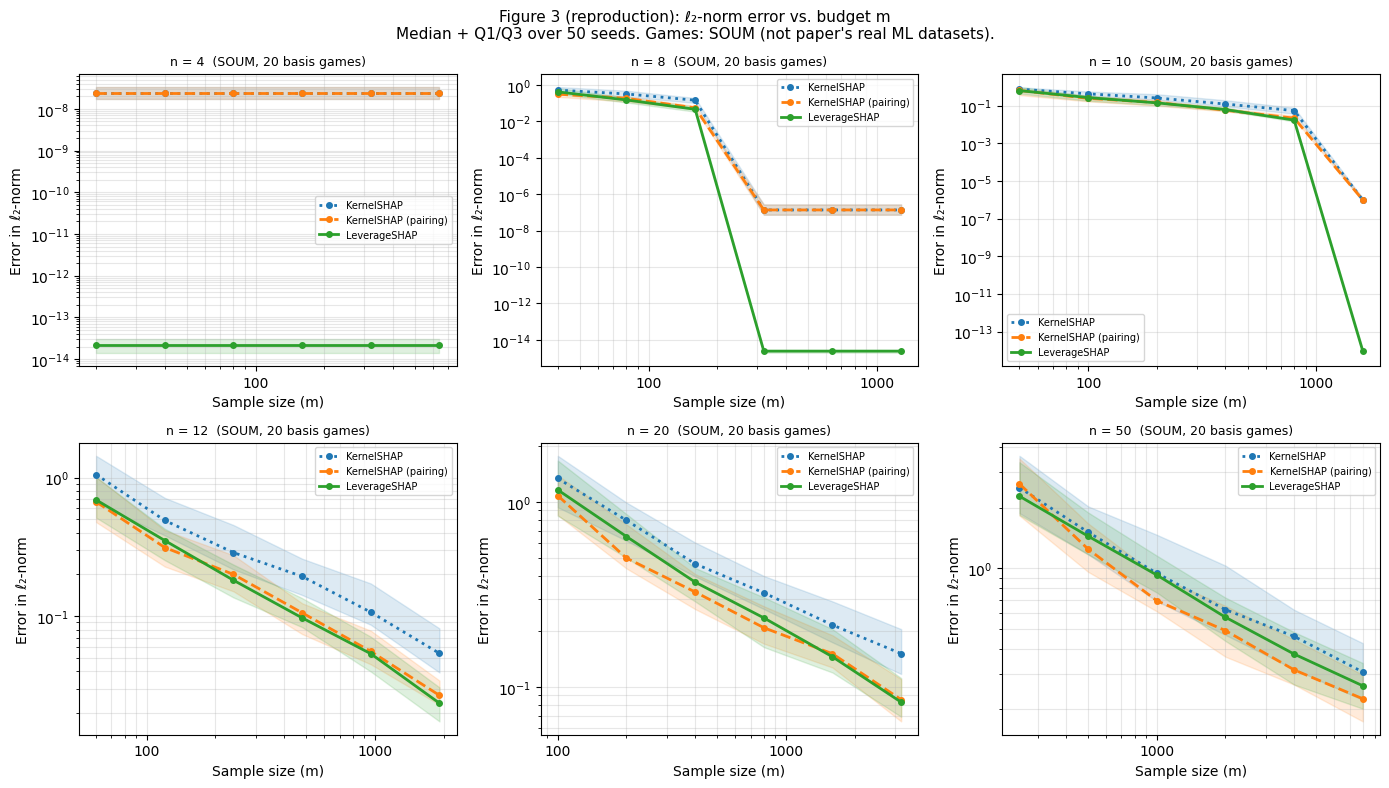

In [6]:
# ── Figure 3: error vs. budget ───────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, n in zip(axes.flat, PLAYER_SIZES):
    budgets = np.array([5*n, 10*n, 20*n, 40*n, 80*n, 160*n])

    for name in ['KernelSHAP', 'KernelSHAP (pairing)', 'LeverageSHAP']:
        data = results[n][name]  # (N_RUNS, 6)
        med = np.median(data, axis=0)
        q1  = np.percentile(data, 25, axis=0)
        q3  = np.percentile(data, 75, axis=0)
        color = COLORS[name]
        ls    = LINESTYLES[name]
        ax.loglog(budgets, med, color=color, ls=ls, lw=2,
                  label=name, marker='o', ms=4)
        ax.fill_between(budgets, q1, q3, alpha=0.15, color=color)

    ax.set_title(f'n = {n}  (SOUM, {N_BASIS} basis games)', fontsize=9)
    ax.set_xlabel('Sample size (m)')
    ax.set_ylabel('Error in ℓ₂-norm')
    ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax.legend(fontsize=7)
    ax.grid(True, which='both', alpha=0.3)

fig.suptitle('Figure 3 (reproduction): ℓ₂-norm error vs. budget m\n'
             f'Median + Q1/Q3 over {N_RUNS} seeds. Games: SOUM (not paper\'s real ML datasets).',
             fontsize=11)
fig.tight_layout()
plt.show()

In [7]:
# ── Table 1: summary statistics at m = 10n ───────────────────────────────────
budget_idx = 1  # index 1 → m = 10n in our budget list

rows = []
for n in PLAYER_SIZES:
    for method in ['KernelSHAP', 'KernelSHAP (pairing)', 'LeverageSHAP']:
        data = results[n][method][:, budget_idx]
        rows.append({
            'n': n,
            'Method': method,
            'Mean':   round(data.mean(), 5),
            'Q1':     round(np.percentile(data, 25), 5),
            'Median': round(np.median(data), 5),
            'Q3':     round(np.percentile(data, 75), 5),
        })

df = pd.DataFrame(rows).set_index(['n', 'Method'])
print('Table 1 equivalent (m = 10n):\n')
print(df.to_string())

Table 1 equivalent (m = 10n):

                            Mean       Q1   Median       Q3
n  Method                                                  
4  KernelSHAP            0.00000  0.00000  0.00000  0.00000
   KernelSHAP (pairing)  0.00000  0.00000  0.00000  0.00000
   LeverageSHAP          0.00000  0.00000  0.00000  0.00000
8  KernelSHAP            0.34563  0.22376  0.31626  0.47537
   KernelSHAP (pairing)  0.18893  0.12160  0.18198  0.22556
   LeverageSHAP          0.15654  0.10739  0.14777  0.19927
10 KernelSHAP            0.46932  0.33551  0.42505  0.56559
   KernelSHAP (pairing)  0.24845  0.16890  0.24379  0.32563
   LeverageSHAP          0.26616  0.18223  0.26790  0.33115
12 KernelSHAP            0.54741  0.38225  0.49008  0.71279
   KernelSHAP (pairing)  0.33997  0.22785  0.31259  0.41659
   LeverageSHAP          0.35587  0.25334  0.35107  0.42652
20 KernelSHAP            0.79821  0.61646  0.79503  0.99154
   KernelSHAP (pairing)  0.57310  0.43663  0.49678  0.75553
   Levera

---
## Section 4 — Why these results don't represent the paper's findings

- **Wrong game type.** The paper uses XGBoost models on real datasets (IRIS, Diabetes, Adult, …). SOUM is a sum of random unanimity games — a synthetic worst-case benchmark, not a realistic model.
- **SOUM is structureless.** Each unanimity game pays off only when a specific random subset is fully present. Summing 20 of them creates a noisy, unstructured value function with no sparse signal to exploit.
- **LeverageSHAP's advantage disappears.** The paper's error bound scales with γ — a measure of how well the Shapley values fit the regression. For real models γ is tiny; for random SOUM games γ ≈ 1, making the bound vacuous.
- **KernelSHAP accidentally wins here.** Its heuristic of over-sampling small and large subsets happens to align with SOUM's structure (unanimity games trigger at specific subset sizes). On real models, that heuristic is a liability.
- **To reproduce the paper**, you would need to run against real ML models and use TreeSHAP as the ground truth.